In [3]:
from plot_utils import find_utts, per_utterance_wer, align_word_sequences
import pandas as pd
import numpy as np
from difflib import SequenceMatcher
from scipy import stats
from scipy.stats import wilcoxon, spearmanr
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util
import re
import os, json
import cv2, pronouncing
from matplotlib_venn import venn2
import seaborn as sns
from g2p_en import G2p

/home/aristosp/anaconda3/envs/avhubert/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def show_wrong_segments_with_context(
    video_path,
    ref,
    visg_hypo,
    avhubert_hypo,
    savepath=None,
    alignment_path=None,
    context=1,
    fps=25,
    mode="better"
):
    """
    Visualize mispredicted words with phone-level alignment for
    baseline AV-HuBERT vs VisG AV-HuBERT, handling missing words.
    """

    # --- Load frames ---
    cap = cv2.VideoCapture(video_path)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
    total_frames = len(frames)

    # --- Prepare words ---
    ref_words = ref.strip().split()
    visg_words = visg_hypo.strip().split()
    base_words = avhubert_hypo.strip().split()

    # --- Select hypothesis to evaluate ---
    if mode == "better":
        chosen_hypo_words = base_words
        aligned_words = align_word_sequences(ref_words, base_words)
        print("✅ Mode: BETTER → visualizing baseline errors (AV-HuBERT)")
    elif mode == "worse":
        chosen_hypo_words = visg_words
        aligned_words = align_word_sequences(ref_words, visg_words)
        print("❌ Mode: WORSE → visualizing VisG AV-HuBERT errors")
    else:
        raise ValueError("mode must be 'better' or 'worse'")

    # --- Identify mispredicted words ---
    wrong_indices = [i for i, (_, _, _, _, match) in enumerate(aligned_words) if not match]
    if not wrong_indices:
        print("✅ No wrong predictions; nothing to visualize.")
        return

    # --- Expand with context ---
    expanded_indices = set()
    for idx in wrong_indices:
        for offset in range(-context, context + 1):
            new_idx = idx + offset
            if 0 <= new_idx < len(aligned_words):
                expanded_indices.add(new_idx)
    expanded_indices = sorted(expanded_indices)

    # --- Pronunciation helpers ---
    def get_pronunciation(word):
        if not word:
            return None
        phones_list = pronouncing.phones_for_word(word.lower())
        if phones_list:
            return phones_list[0].split()
        return None

    def infer_predicted_phones(word):
        if not word:
            return None
        g2p = G2p()
        phones_list = pronouncing.phones_for_word(word.lower())
        if phones_list:
            return phones_list[0].split()
        try:
            predicted = g2p(word.lower())
            phones = [re.sub(r"\d", "", p) for p in predicted if p not in [" ", ""]]
            if phones:
                return phones
        except Exception:
            pass
        return None

    # --- Load alignment if available ---
    if alignment_path and os.path.exists(alignment_path):
        print("🕒 Using phone-level alignment visualization...")
        alignment_df = pd.read_csv(alignment_path)
        words_df = alignment_df[alignment_df["Type"] == "words"].copy().reset_index(drop=True)
        phones_df = alignment_df[alignment_df["Type"] == "phones"].copy().reset_index(drop=True)

        word_labels_list = words_df["Label"].str.lower().tolist()
        word_begins = words_df["Begin"].tolist()
        word_ends = words_df["End"].tolist()

        # Map reference words to time ranges
        ref_words_lower = [w.lower() for w in ref_words]
        word_time_ranges = {}
        ref_idx_counter = 0
        for i, label in enumerate(word_labels_list):
            if ref_idx_counter < len(ref_words_lower) and ref_words_lower[ref_idx_counter] == label:
                word_time_ranges[ref_idx_counter] = (word_begins[i], word_ends[i])
                ref_idx_counter += 1

        # Map phones → words
        word_to_phones = {}
        for phone_idx, phone_row in phones_df.iterrows():
            for ref_idx, (begin, end) in word_time_ranges.items():
                if (phone_row["Begin"] >= begin and phone_row["Begin"] < end) or \
                   (phone_row["End"] > begin and phone_row["End"] <= end) or \
                   (phone_row["Begin"] <= begin and phone_row["End"] >= end):
                    word_to_phones.setdefault(ref_idx, []).append(phone_idx)
                    break

        # Frames from alignment
        phones_df["begin_frame"] = (phones_df["Begin"] * fps).round().astype(int)
        phones_df["end_frame"] = (phones_df["End"] * fps).round().astype(int)

        word_images, word_labels_meta = [], []

        for idx in expanded_indices:
            ref_idx, hypo_idx, ref_word, hypo_word, is_match = aligned_words[idx]

            # Skip if reference word is missing (insertion in hypo)
            if ref_idx is None:
                continue

            is_wrong = not is_match

            # Get corresponding words from both hypotheses
            base_word = base_words[hypo_idx] if (mode == "better" and hypo_idx is not None and hypo_idx < len(base_words)) else None
            visg_word = visg_words[hypo_idx] if (mode == "worse" and hypo_idx is not None and hypo_idx < len(visg_words)) else None
            
            # For the non-selected hypothesis, get the word using ref_idx
            if mode == "better":
                # We're evaluating base_words, so get visg_word from alignment
                visg_aligned = align_word_sequences(ref_words, visg_words)
                for v_idx, (v_ref_idx, v_hypo_idx, _, v_hypo_word, _) in enumerate(visg_aligned):
                    if v_ref_idx == ref_idx and v_hypo_idx is not None:
                        visg_word = v_hypo_word
                        break
            else:
                # We're evaluating visg_words, so get base_word from alignment
                base_aligned = align_word_sequences(ref_words, base_words)
                for b_idx, (b_ref_idx, b_hypo_idx, _, b_hypo_word, _) in enumerate(base_aligned):
                    if b_ref_idx == ref_idx and b_hypo_idx is not None:
                        base_word = b_hypo_word
                        break

            # Expected phones
            expected_phones = get_pronunciation(ref_word)
            # Baseline phones
            avhubert_phones = infer_predicted_phones(base_word)
            # VisG phones
            visg_phones = infer_predicted_phones(visg_word)

            phone_frames = []
            if ref_idx in word_to_phones:
                for i, phone_idx in enumerate(word_to_phones[ref_idx]):
                    row = phones_df.loc[phone_idx]
                    start_f = max(0, row["begin_frame"])
                    end_f = min(row["end_frame"], total_frames)
                    mid_f = start_f if start_f >= end_f else (start_f + end_f) // 2
                    if mid_f >= total_frames:
                        continue
                    frame = frames[mid_f].copy()

                    # Frame-level red border for differing phonemes
                    diff_phone_indices = []
                    if avhubert_phones and visg_phones:
                        min_len = min(len(avhubert_phones), len(visg_phones))
                        diff_phone_indices = [j for j in range(min_len) if avhubert_phones[j] != visg_phones[j]]

                    if i in diff_phone_indices:
                        frame[:5, :] = [255, 0, 0]
                        frame[-5:, :] = [255, 0, 0]
                        frame[:, :5] = [255, 0, 0]
                        frame[:, -5:] = [255, 0, 0]

                    phone_frames.append(frame)

            if not phone_frames:
                continue

            word_strip = np.hstack(phone_frames)
            word_images.append(word_strip)
            word_labels_meta.append({
                "ref": ref_word,
                "expected_phones": expected_phones,
                "avhubert_phones": avhubert_phones,
                "visg_phones": visg_phones,
                "base_hypo": base_word if base_word else "",
                "visg_hypo": visg_word if visg_word else "",
                "is_wrong": is_wrong,
                "ref_idx": ref_idx
            })

    else:
        print("🖼️ No alignment file; cannot visualize.")
        return

    # --- Plot ---
    n_words = len(word_images)
    fig = plt.figure(figsize=(20, n_words * 3.5))
    gs = fig.add_gridspec(n_words, 1, hspace=0.5)

    for i, (img, label) in enumerate(zip(word_images, word_labels_meta)):
        ax = fig.add_subplot(gs[i])
        ax.imshow(img)
        color = "red" if label["is_wrong"] else "blue"

        # Get hypothesis text based on mode
        if mode == "better":
            hyp_title = "VisG AV-HuBERT"
            hypo_text = label['base_hypo']
        elif mode == "worse":
            hyp_title = "VisG AV-HuBERT"
            hypo_text = label['visg_hypo']
        else:
            hyp_title = "Hypothesis"
            hypo_text = label['base_hypo'] if mode == "better" else label['visg_hypo']

        # Build title
        title = f"REF='{label['ref']}' | HYP ({hyp_title})='{hypo_text}'\n\n"
        title += f"Expected: [{' '.join(label['expected_phones']) if label['expected_phones'] else '(none)'}]\n"
        title += f"AV-HuBERT: [{' '.join(label['avhubert_phones']) if label['avhubert_phones'] else '(none)'}]\n"
        title += f"VisG AV-HuBERT: [{' '.join(label['visg_phones']) if label['visg_phones'] else '(none)'}]"

        ax.set_title(title, color=color, fontsize=11,
                     fontweight="bold" if label["is_wrong"] else "normal", pad=10)
        ax.axis("off")

    # --- Footer text ---
    fig.text(0.5, 0.08, f"REFERENCE: {ref}", fontsize=12, color="black", ha="center", weight="bold")
    fig.text(0.5, 0.05, f"AV-HuBERT Hypo: {avhubert_hypo}", fontsize=12, color="red", ha="center", weight="bold")
    fig.text(0.5, 0.02, f"VisG AV-HuBERT Hypo: {visg_hypo}", fontsize=12, color="green", ha="center", weight="bold")

    plt.subplots_adjust(bottom=0.1, top=0.98)
    if savepath:
        plt.savefig(savepath, bbox_inches="tight")
        plt.close(fig)
        print(f"Visualization saved to: {savepath}")
    else:
        plt.show()


In [5]:
model = 'large'
noise_type = None
snr = -10
experiment_params = {
                'Name': 'Exp5'
            }
noise_path = f'{noise_type}_snr{snr}' if noise_type else None

In [6]:
if noise_type is not None:
    with open(f'/home/aristosp/models/av_hubert/{model}_decode/{noise_path}/hypo-244018.json', 'r') as baseline_file:
        baseline_data = json.load(baseline_file)
    with open(f'/home/aristosp/viseme_{model}_models/{experiment_params["Name"]}/decode/{noise_path}/hypo-244018.json', 'r') as f2:
        vsm_data = json.load(f2)  
else:
    with open(f'/home/aristosp/models/av_hubert/{model}_decode/hypo-244018.json', 'r') as baseline_file:
        baseline_data = json.load(baseline_file)
    # Read viseme model JSON
    with open(f'/home/aristosp/viseme_{model}_models/{experiment_params["Name"]}/decode/hypo-244018.json', 'r') as f2:
        vsm_data = json.load(f2)

In [7]:
# Remove zeros, i.e. only focus on changed WERs
# Per utterance Word Error Rate (WER)
baseline_per_utt_wer, avg_baseline_wer, baseline_sids = per_utterance_wer(baseline_data)

vsm_per_utt, vsm_avg, vsm_sids = per_utterance_wer(vsm_data)
diff = vsm_per_utt - baseline_per_utt_wer 
nonzero_idx = diff != 0
diff_nonzero = diff[nonzero_idx]

# Get indices for plotting
indices = np.arange(len(diff))[nonzero_idx]
# Separate positive and negative differences
pos_idx = diff_nonzero > 0 # baseline better
neg_idx = diff_nonzero < 0 # viseme better
worse_utts = []
better_utts = []
better_utts, worse_utts = find_utts(indices[neg_idx], indices[pos_idx], vsm_data, baseline_data)




✅ Mode: BETTER → visualizing baseline errors (AV-HuBERT)
🕒 Using phone-level alignment visualization...


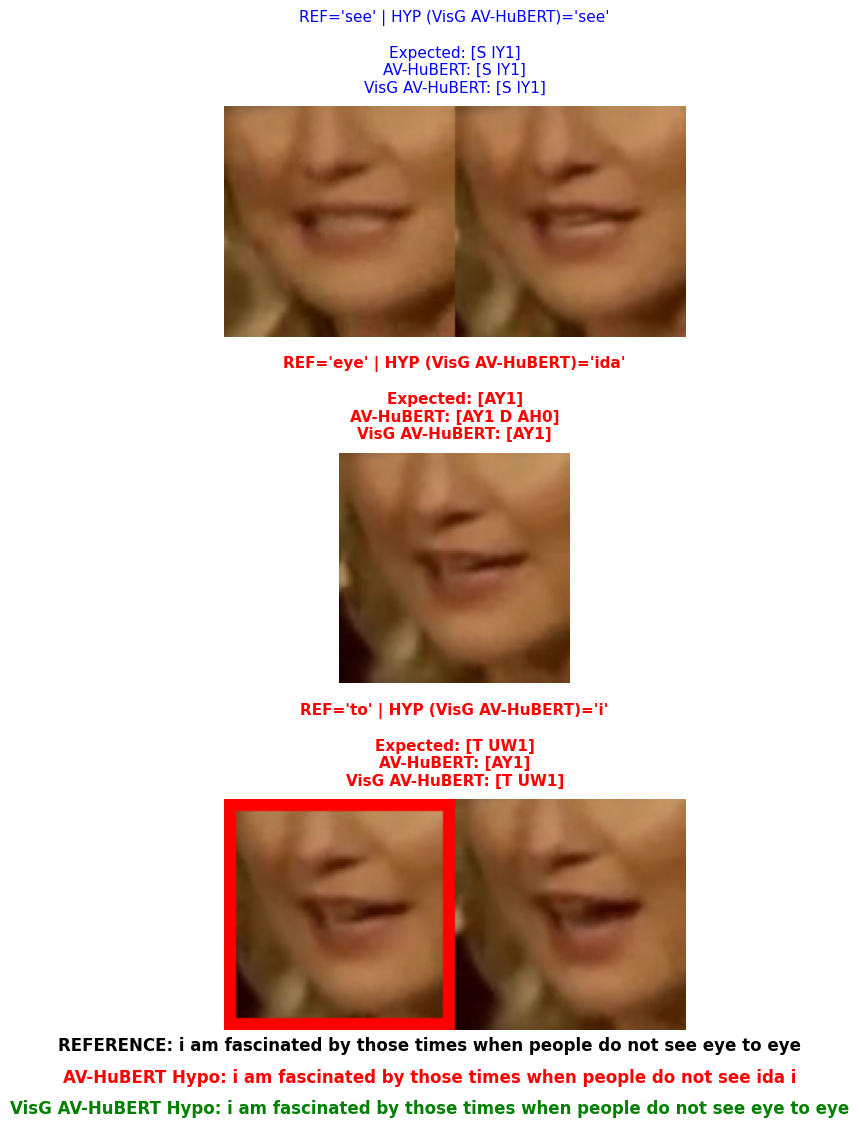

❌ Mode: WORSE → visualizing VisG AV-HuBERT errors
🕒 Using phone-level alignment visualization...


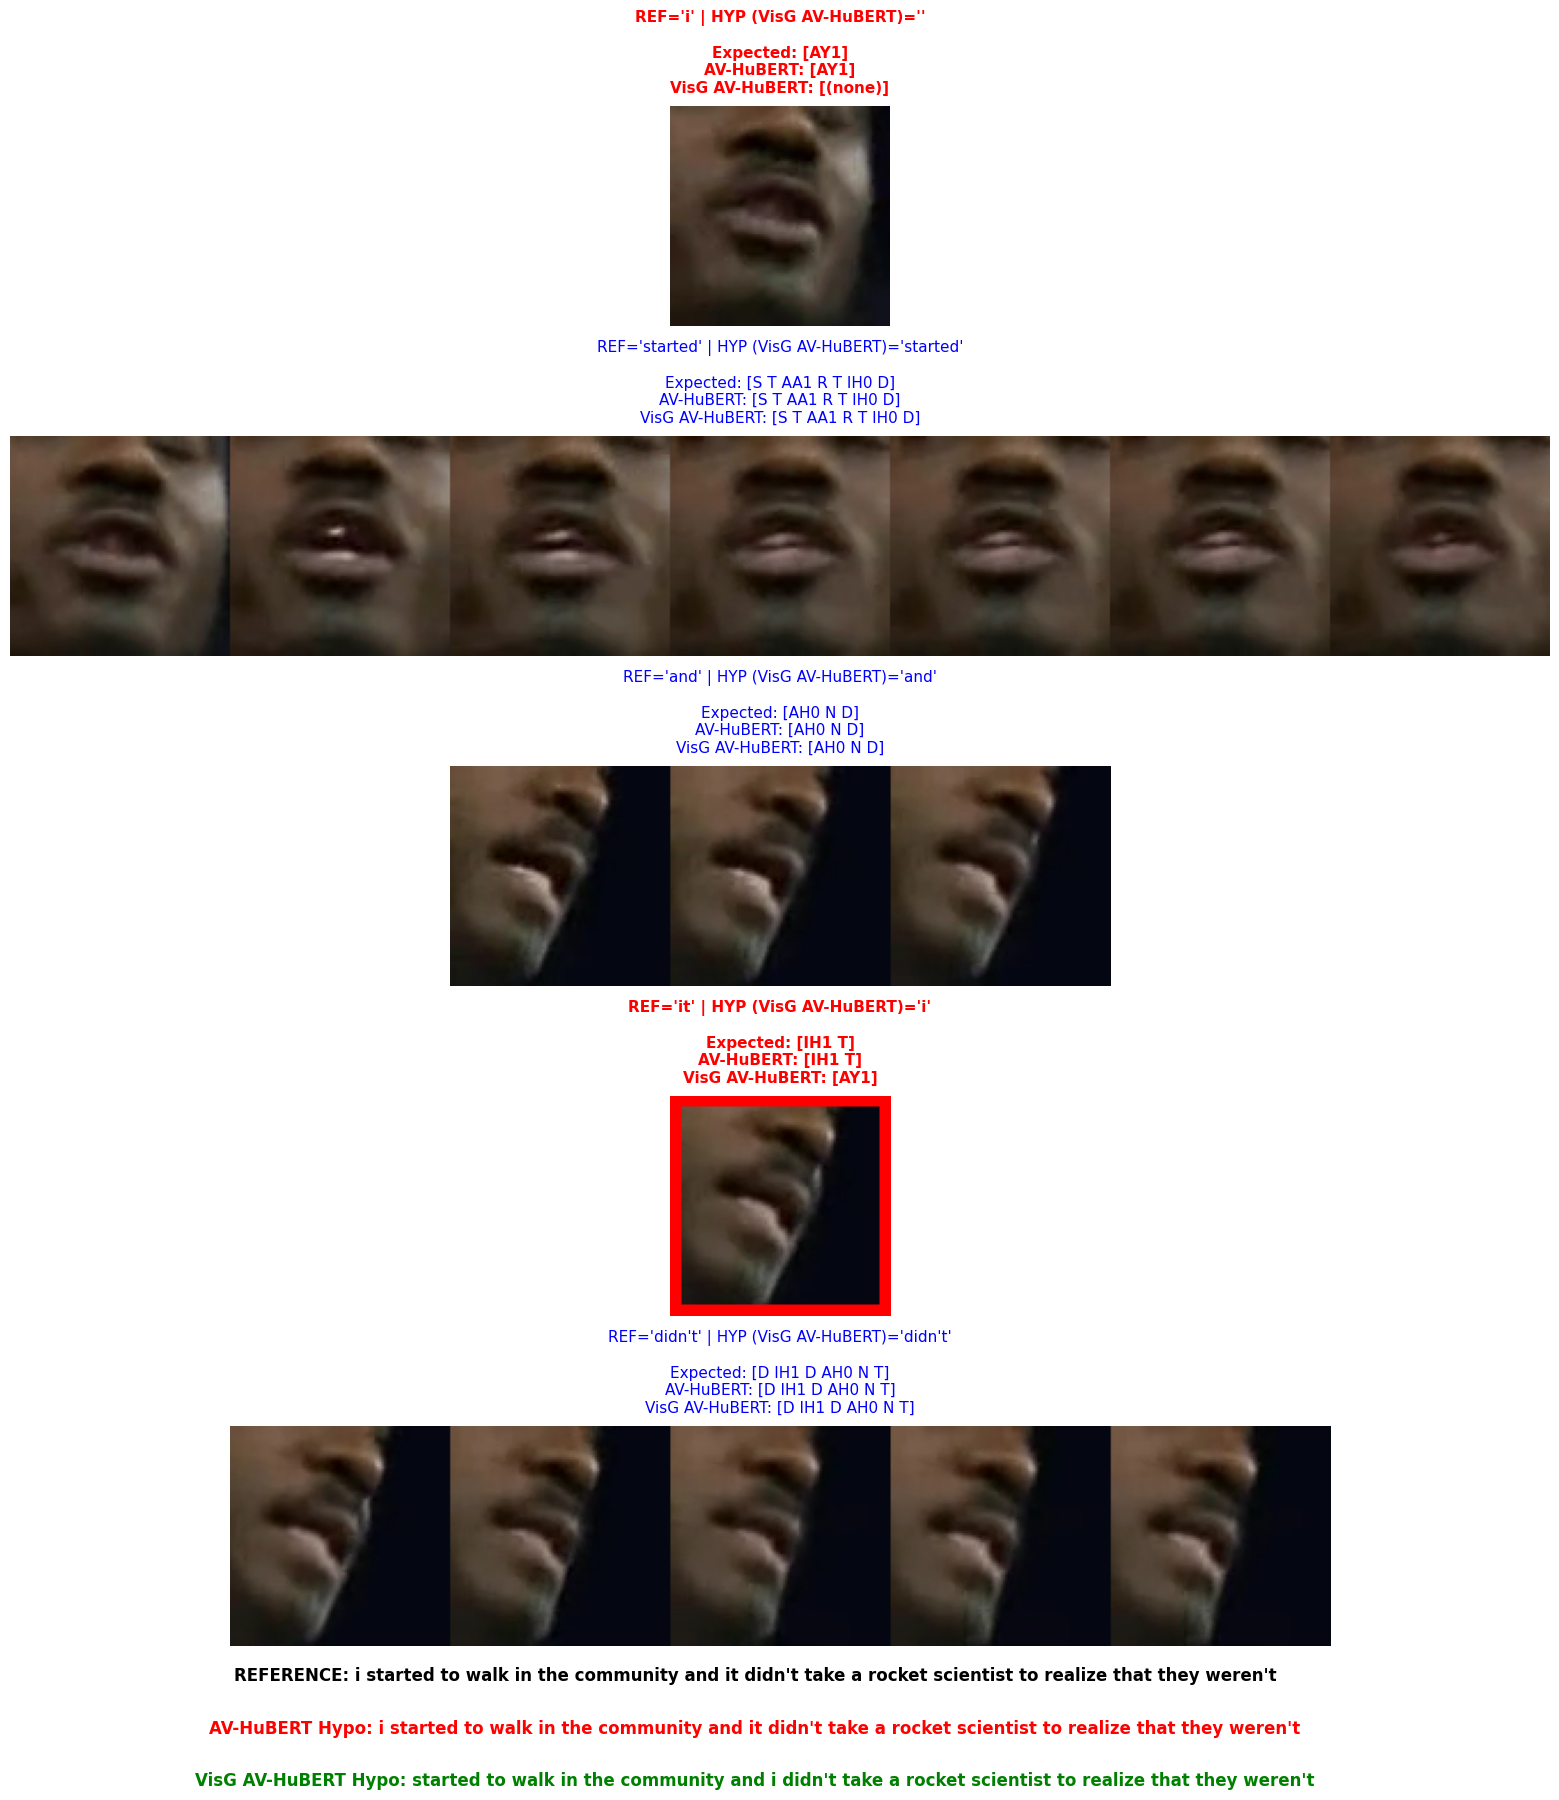

In [8]:
examples = {
                "better": better_utts[3],
                "worse": worse_utts[1]
            }

for quality, example in examples.items():
    dataset, speaker, file = example.split('/')
    example_filename = f"{speaker}_{file}"

    video_path = f"/home/aristosp/datasets/LRS3/roi/{example}.mp4"
    alignment_path = f"/home/aristosp/datasets/LRS3/audio/aligned/{example}.csv"

    idx = vsm_data['utt_id'].index(example)
    ref = vsm_data['ref'][idx]
    show_wrong_segments_with_context(video_path, ref, visg_hypo=vsm_data['hypo'][idx], avhubert_hypo=baseline_data['hypo'][idx], alignment_path=alignment_path, mode=quality)
